## Experiment No: 4
## Experiment Title: Polynomial Regression with Varying Degrees - Effect of Model Complexity on Bias-Variance Trade-off

**Name:** Himanshu Jadhav  
**Roll Number:** TE-33

### Step 1: Import Required Libraries

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(33)

### Step 2: Generate a Sample Non-Linear Dataset

In [3]:
x      = np.sort(np.random.uniform(0, 10, 80)).reshape(-1, 1)
y_true = np.sin(x).ravel()
noise  = np.random.normal(0, 0.3, x.shape[0])  # Real-data is messy, so we add some noise to the data
y      = y_true + noise

df = pd.DataFrame({"x": x.ravel(), "y": y})
print("Shape of Dataset: ", df.shape)
df.head()





Shape of Dataset:  (80, 2)


,x,y
0,0.173720,-0.023220
1,0.196614,0.353686
2,0.317078,0.591608
3,0.557383,0.495549
4,0.594943,0.224247


### Step 3: Visualize the Raw Data

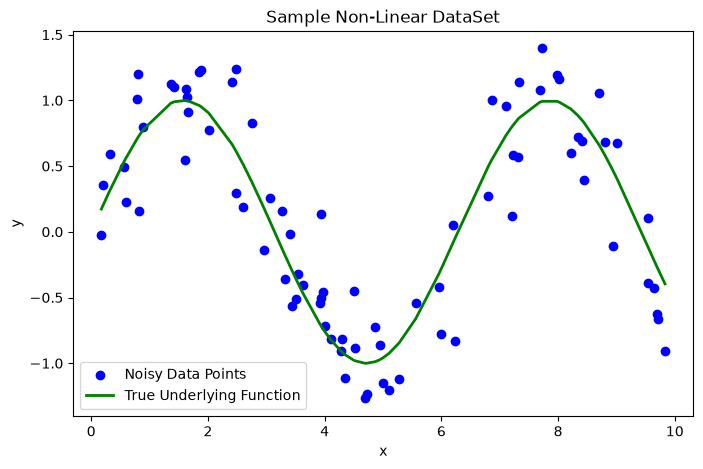

In [4]:
plt.figure(figsize=(8, 5))
plt.scatter(x, y, color="blue", label="Noisy Data Points")
plt.plot(x, y_true, color="green", linewidth=2, label="True Underlying Function")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Sample Non-Linear DataSet")
plt.legend()
plt.show()

### Step 4: Split Data Into Training and Testing Sets

In [6]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=33
)

print("Training Set Size: ", x_train.shape)
print("Testing  Set Size: ", x_test.shape)

Training Set Size:  (56, 1)
Testing  Set Size:  (24, 1)


### Step 5: Train Polynomial Regression Models of Different Degrees

In [7]:
# We will try multiple polynomial degrees to observe underfitting vs overfitting
degrees = [1, 2, 4, 8, 15]

# Dictionaries to store results for comparison later
train_errors = {}
test_errors = {}
r2_scores = {}
models = {}
poly_transformers = {}

In [9]:
for degree in degrees:
    poly         = PolynomialFeatures(degree=degree)
    x_train_poly = poly.fit_transform(x_train)
    x_test_poly  = poly.transform(x_test)

    model        = LinearRegression()
    model.fit(x_train_poly, y_train)

    y_train_pred = model.predict(x_train_poly)
    y_test_pred  = model.predict(x_test_poly)

    train_mse    = mean_squared_error(y_train, y_train_pred)
    test_mse     = mean_squared_error(y_test, y_test_pred)
    test_r2      = r2_score(y_test, y_test_pred)

    train_errors[degree]      = train_mse
    test_errors[degree]       = test_mse
    r2_scores[degree]         = test_r2
    models[degree]            = model
    poly_transformers[degree] = poly

    print(f"Degree: {degree:2d} | Train MSE: {train_mse:.4f} | Test MSE: {test_mse:.4f} | Test R2: {test_r2:.4f}")

Degree:  1 | Train MSE: 0.5815 | Test MSE: 0.6186 | Test R2: 0.0048
Degree:  2 | Train MSE: 0.4956 | Test MSE: 0.5053 | Test R2: 0.1870
Degree:  4 | Train MSE: 0.1130 | Test MSE: 0.1339 | Test R2: 0.7845
Degree:  8 | Train MSE: 0.1202 | Test MSE: 0.1683 | Test R2: 0.7293
Degree: 15 | Train MSE: 0.4743 | Test MSE: 0.4865 | Test R2: 0.2173


### Step 6: Tabulate the Results 

In [12]:
results_df = pd.DataFrame({
    "Degree"    : degrees,
    "Train MSE" : [train_errors[d] for d in degrees],
    "Test MSE"  : [test_errors[d] for d in degrees],
    "Test R2"   : [r2_scores[d] for d in degrees]
})

print("\nSummary of Results:")
print(results_df.to_string(index=False))


Summary of Results:
 Degree  Train MSE  Test MSE  Test R2
      1   0.581486  0.618550 0.004837
      2   0.495599  0.505346 0.186967
      4   0.113042  0.133932 0.784521
      8   0.120202  0.168284 0.729254
     15   0.474290  0.486495 0.217296


### Step 7: Visualize Fitted Curves for Different Polynomial Degrees

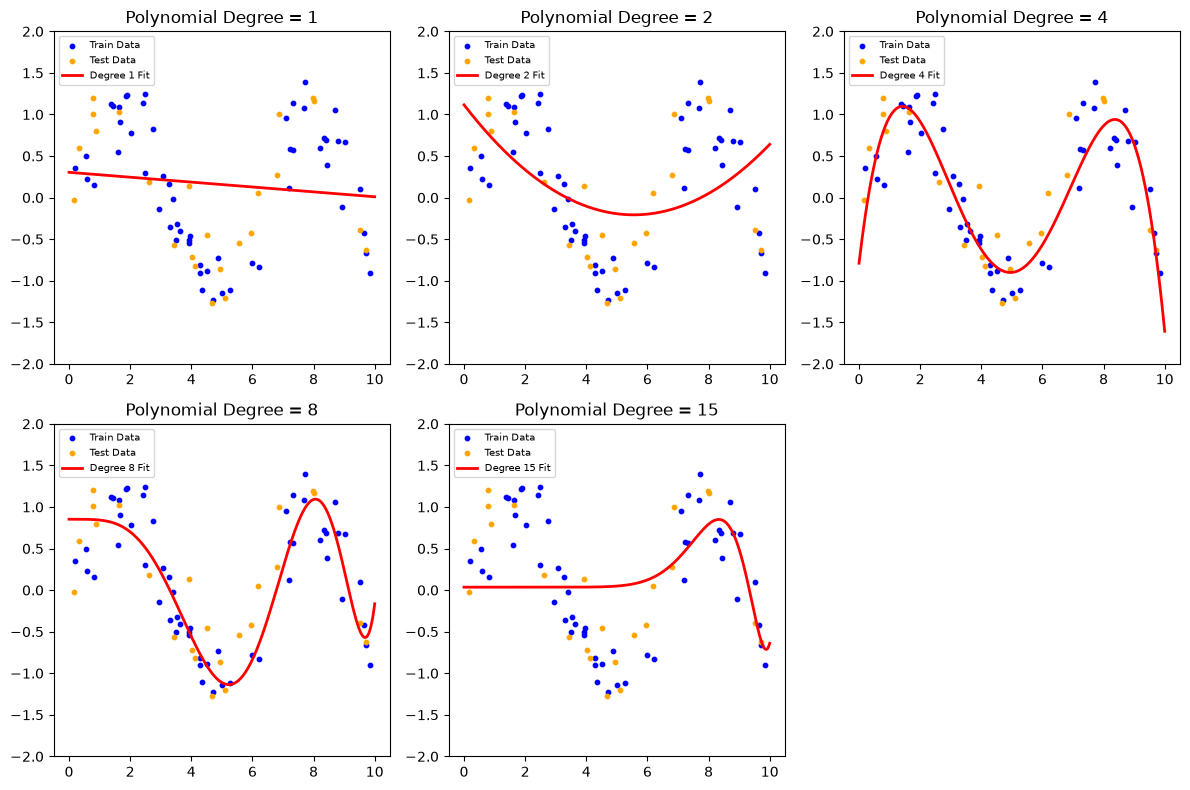

In [13]:
plt.figure(figsize=(12, 8))
x_plot = np.linspace(0, 10, 300).reshape(-1, 1)

for i, degree in enumerate(degrees):
    plt.subplot(2, 3, i + 1)
    plt.scatter(x_train, y_train, color="blue", s=10, label="Train Data")
    plt.scatter(x_test, y_test, color="orange", s=10, label="Test Data")

    # Transforming the plotting range using the same polynomial degree
    x_plot_poly = poly_transformers[degree].transform(x_plot)
    y_plot_pred = models[degree].predict(x_plot_poly)

    plt.plot(x_plot, y_plot_pred, color="red", linewidth=2, label=f"Degree {degree} Fit")
    plt.title(f"Polynomial Degree = {degree}")
    plt.ylim(-2, 2)
    plt.legend(fontsize=7)

plt.tight_layout()
plt.show()

### Step 8: Visualize the Bias-Variance Trade-off (Train Vs Test Error)

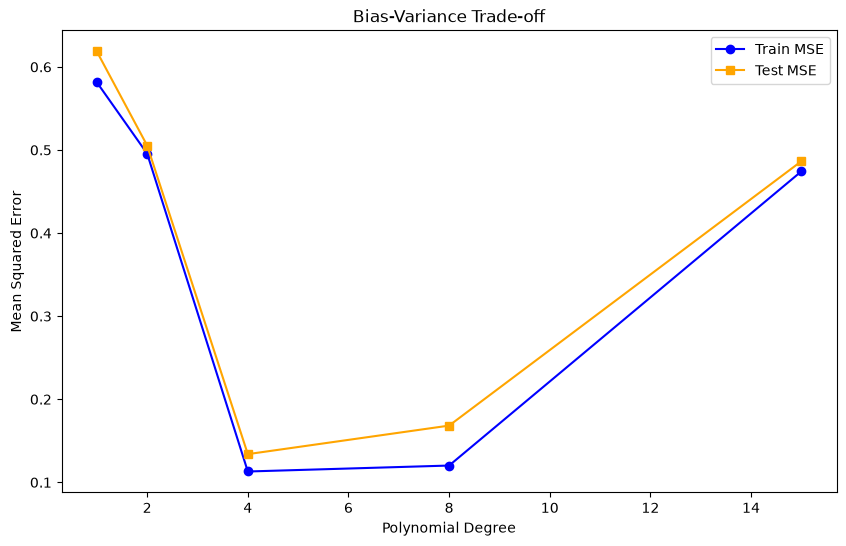


Interpretation:
- Low degree (e.g. 1) -> High Train & Test error -> Underfitting (High Bias)
- Moderate degree (e.g. 4) -> Low Train & Test error -> Good Fit
- High degree (e.g. 15) -> Very Low Train error but High Test error -> Overfitting (High Variance)


In [18]:
plt.figure(figsize=(10, 6))
plt.plot(degrees, [train_errors[d] for d in degrees], marker='o', label="Train MSE", color="blue")
plt.plot(degrees, [test_errors[d] for d in degrees],  marker='s', label="Test MSE", color="orange")
plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.title("Bias-Variance Trade-off")
plt.legend()
plt.show()

print("\nInterpretation:")
print("- Low degree (e.g. 1) -> High Train & Test error -> Underfitting (High Bias)")
print("- Moderate degree (e.g. 4) -> Low Train & Test error -> Good Fit")
print("- High degree (e.g. 15) -> Very Low Train error but High Test error -> Overfitting (High Variance)")


### Step 9: Final Output 

In [17]:
print("Experiment Completed Successfully")
print("\nFinal Comparison Table:")
print(results_df)

Experiment Completed Successfully

Final Comparison Table:
   Degree  Train MSE  Test MSE   Test R2
0       1   0.581486  0.618550  0.004837
1       2   0.495599  0.505346  0.186967
2       4   0.113042  0.133932  0.784521
3       8   0.120202  0.168284  0.729254
4      15   0.474290  0.486495  0.217296
